In [1]:
# ============================================================
# ALEXNET + BAYESIAN OPTIMIZATION (FAST VERSION)
# ============================================================

import os, cv2, zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/pld-foldds/PLD_FOLDDATASET"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ---------------- LOAD DATA ----------------
def load_data(folder):
    paths, labels = [], []
    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        for f in os.listdir(os.path.join(folder, cls)):
            paths.append(os.path.join(folder, cls, f))
            labels.append(idx)

    return np.array(paths), np.array(labels), classes

X_train, y_train, class_names = load_data(TRAIN_DIR)
X_val, y_val, _ = load_data(VAL_DIR)
X_test, y_test, _ = load_data(TEST_DIR)

NUM_CLASSES = len(class_names)

# ---------------- GENERATOR ----------------
def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment and np.random.rand() < 0.5:
                    img = cv2.flip(img, 1)

                img = img.astype("float32") / 255.0
                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, NUM_CLASSES)

# ---------------- MODEL BUILDER ----------------
def build_model(hp):

    model = models.Sequential()

    model.add(layers.Conv2D(96, (11,11), strides=4, activation='relu',
                            input_shape=(IMG_SIZE, IMG_SIZE, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(3,2))

    model.add(layers.Conv2D(256, (5,5), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(3,2))

    model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(384, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(3,2))

    model.add(layers.Flatten())

    # 🔥 Tunable dense layer
    dense_units = hp.Int("dense_units", 512, 1024, step=256)
    model.add(layers.Dense(dense_units, activation='relu'))

    # 🔥 Tunable dropout
    dropout = hp.Float("dropout", 0.3, 0.6, step=0.1)
    model.add(layers.Dropout(dropout))

    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    # 🔥 Tunable LR
    lr = hp.Choice("lr", [1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ---------------- TUNER ----------------
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=3,   # 🔥 as requested
    directory="/kaggle/working/tuner",
    project_name="alexnet_bayes"
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True
)

# ---------------- SEARCH ----------------
tuner.search(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_data=generator(X_val, y_val),
    validation_steps=len(X_val)//BATCH_SIZE,
    epochs=5,
    callbacks=[early_stop]
)

# ---------------- BEST MODEL ----------------
best_model = tuner.get_best_models(1)[0]

print("✅ Best hyperparameters selected")

# ---------------- FINAL TRAIN ----------------
history = best_model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_data=generator(X_val, y_val),
    validation_steps=len(X_val)//BATCH_SIZE,
    epochs=15
)

# ---------------- SAVE ----------------
SAVE_PATH = "/kaggle/working/alexnet_bayes.h5"
best_model.save(SAVE_PATH)

ZIP_PATH = "/kaggle/working/alexnet_bayes.zip"
with zipfile.ZipFile(ZIP_PATH, 'w') as z:
    z.write(SAVE_PATH, arcname="alexnet_bayes.h5")

print("📦 Model saved & zipped")

# ---------------- TEST ----------------
y_true, y_pred = [], []
test_gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(test_gen)
    preds = best_model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

print("\n✅ Test Accuracy:", np.mean(y_true == y_pred))

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Trial 3 Complete [00h 06m 02s]
val_accuracy: 0.9253333210945129

Best val_accuracy So Far: 0.9781420826911926
Total elapsed time: 00h 22m 51s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Best hyperparameters selected
Epoch 1/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 81s 132ms/step - accuracy: 0.9774 - loss: 0.0681 - val_accuracy: 0.8620 - val_loss: 0.4021
Epoch 2/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 79s 134ms/step - accuracy: 0.9836 - loss: 0.0452 - val_accuracy: 0.8672 - val_loss: 0.5064
Epoch 3/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 80s 140ms/step - accuracy: 0.9813 - loss: 0.0528 - val_accuracy: 0.9740 - val_loss: 0.0912
Epoch 4/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.9901 - loss: 0.0327 - val_accuracy: 0.9867 - val_loss: 0.0460
Epoch 5/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 83s 146ms/step - accuracy: 0.9896 - loss: 0.0306 - val_accuracy: 0.9922 - val_loss: 0.0311
Epoch 6/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 75s 132ms/step - accuracy: 0.9916 - loss: 0.0255 - val_accuracy: 0.9547 - val_loss: 0.1334
Epoch 7/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 72s 126ms/step - accuracy: 0.9903 - loss: 0.0328 - val_accuracy: 0.8747 - val_loss: 0.4989
Epoch 8/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 73s 127ms/s

📦 Model saved & zipped

✅ Test Accuracy: 0.9852941176470589

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight       0.96      1.00      0.98       163
     Healthy       1.00      0.94      0.97       102
  LateBlight       1.00      1.00      1.00       143

    accuracy                           0.99       408
   macro avg       0.99      0.98      0.98       408
weighted avg       0.99      0.99      0.99       408



In [4]:
# ============================================================
# DOMAIN ADAPTATION + FINE-TUNING (ALEXNET - FINAL FIXED)
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/potatoleafplantvillage/PlantVillageExtended/Test"

IMG_SIZE = 224   # ✅ IMPORTANT (AlexNet compatible)
BATCH_SIZE = 32
EPOCHS = 10

# ---------------- LOAD MODEL ----------------
MODEL_PATH = "/kaggle/working/alexnet_bayes.h5"
model = load_model(MODEL_PATH)

# ---------------- CLASS ORDER ----------------
class_names = ["EarlyBlight", "Healthy", "LateBlight"]

# ============================================================
# ROBUST DATA LOADING (AUTO MATCHING)
# ============================================================

paths, labels = [], []

for cls in os.listdir(DATASET_DIR):

    cls_lower = cls.lower()

    if "early" in cls_lower:
        label = class_names.index("EarlyBlight")
    elif "late" in cls_lower:
        label = class_names.index("LateBlight")
    elif "healthy" in cls_lower:
        label = class_names.index("Healthy")
    else:
        print("Skipping:", cls)
        continue

    cls_dir = os.path.join(DATASET_DIR, cls)

    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.jpg','.png','.jpeg')):
            paths.append(os.path.join(cls_dir, f))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("✅ Total loaded samples:", len(paths))

if len(paths) == 0:
    raise ValueError("❌ No data loaded. Check dataset path.")

# ============================================================
# SPLIT (DOMAIN ADAPTATION SETUP)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    paths, labels,
    test_size=0.8,
    stratify=labels,
    random_state=42
)

print("Adaptation train:", len(X_train))
print("Test:", len(X_test))

# ============================================================
# DATA GENERATOR (FIXED FOR ALEXNET)
# ============================================================

def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # 🔥 AUGMENTATION
                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)
                    if np.random.rand() < 0.3:
                        img = cv2.convertScaleAbs(img, alpha=1.2, beta=25)
                    if np.random.rand() < 0.3:
                        img = cv2.GaussianBlur(img, (3,3), 0)

                # ✅ CORRECT NORMALIZATION
                img = img.astype("float32") / 255.0

                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, 3)

# ============================================================
# FINE-TUNING (SAFE FOR ALEXNET)
# ============================================================

# Only unfreeze last layers (avoid instability)
for layer in model.layers[-10:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# TRAINING
# ============================================================

history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    epochs=EPOCHS,
    verbose=1
)

# ============================================================
# TESTING
# ============================================================

y_true, y_pred = [], []
gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ============================================================
# RESULTS
# ============================================================

acc = np.mean(y_true == y_pred)
print(f"\n✅ Improved Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

✅ Total loaded samples: 2152
Adaptation train: 430
Test: 1722
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.6914 - loss: 1.8768
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 380ms/step - accuracy: 0.7577 - loss: 1.1931
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 289ms/step - accuracy: 0.8105 - loss: 0.9376
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.8344 - loss: 0.6397
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step - accuracy: 0.8455 - loss: 0.5750
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 306ms/step - accuracy: 0.8450 - loss: 0.7247
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 423ms/step - accuracy: 0.8964 - loss: 0.4213
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 517ms/step - accuracy: 0.8693 - loss: 0.3777
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 478ms/step - accuracy: 0.9119 - loss: 0.3198
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 447ms/step - accuracy: 0.9147 - loss: 0.2491

✅ Improved Accuracy: 0.8432

📊 Classification Report:
              precisio

Train: 18257 Val: 407 Test: 408
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_56"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,288,579 (77.39 MB)

 Trainable params: 264,195 (1.01 MB)

...

Epoch 1/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 135s 215ms/step - accuracy: 0.7392 - loss: 0.8865 - val_accuracy: 0.9740 - val_loss: 0.0904
Epoch 2/10


2026-05-03 08:14:43.675581: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:14:43.914129: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:14:44.824503: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:14:45.086181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


570/570 ━━━━━━━━━━━━━━━━━━━━ 196s 332ms/step - accuracy: 0.9411 - loss: 0.1627 - val_accuracy: 0.9844 - val_loss: 0.0416
Epoch 3/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 126s 221ms/step - accuracy: 0.9641 - loss: 0.1025 - val_accuracy: 0.9870 - val_loss: 0.0416
Epoch 4/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9726 - loss: 0.0759

2026-05-03 08:22:04.375820: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:22:04.615271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:22:05.706789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:22:05.970906: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


570/570 ━━━━━━━━━━━━━━━━━━━━ 127s 223ms/step - accuracy: 0.9726 - loss: 0.0759 - val_accuracy: 0.9840 - val_loss: 0.0366
Epoch 5/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 111s 194ms/step - accuracy: 0.9802 - loss: 0.0586 - val_accuracy: 0.9867 - val_loss: 0.0285
Epoch 6/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 115s 202ms/step - accuracy: 0.9848 - loss: 0.0462 - val_accuracy: 0.9867 - val_loss: 0.0224
Epoch 7/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 89s 156ms/step - accuracy: 0.9880 - loss: 0.0352 - val_accuracy: 0.9973 - val_loss: 0.0106
Epoch 8/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 87s 153ms/step - accuracy: 0.9896 - loss: 0.0315 - val_accuracy: 0.9947 - val_loss: 0.0123
Epoch 9/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 104s 182ms/step - accuracy: 0.9933 - loss: 0.0252 - val_accuracy: 0.9947 - val_loss: 0.0123
Epoch 10/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 131s 230ms/step - accuracy: 0.9934 - loss: 0.0200 - val_accuracy: 0.9973 - val_loss: 0.0117

✅ Test Accuracy: 0.9926

📊 Classification Report:
              precision    recall  f1

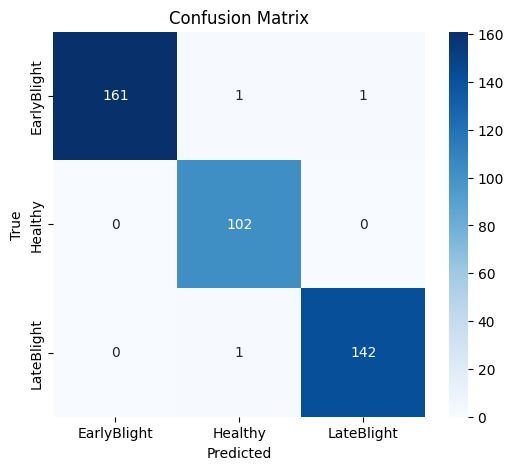

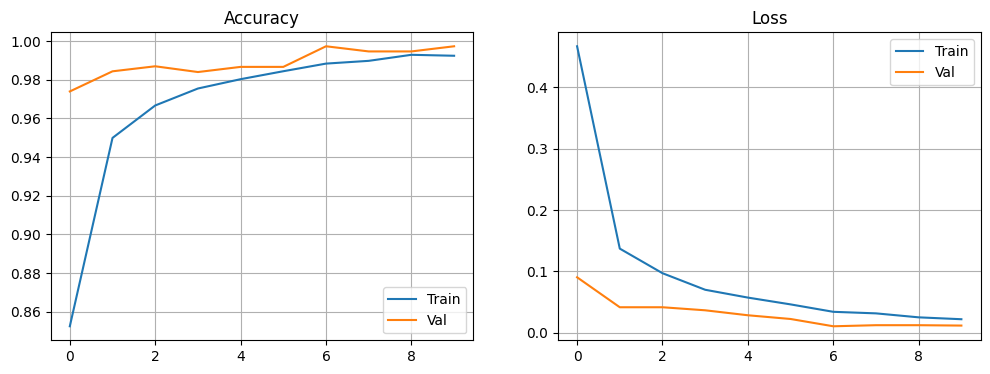

In [5]:
# ============================================================
# VGG19 PIPELINE (256x256) + FULL EVALUATION
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/pld-foldds/PLD_FOLDDATASET"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 256   # ✅ as requested
BATCH_SIZE = 32
EPOCHS = 10

# ---------------- LOAD DATA ----------------
def load_data(folder):
    paths, labels = [], []
    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        for f in os.listdir(os.path.join(folder, cls)):
            paths.append(os.path.join(folder, cls, f))
            labels.append(idx)

    return np.array(paths), np.array(labels), classes

X_train, y_train, class_names = load_data(TRAIN_DIR)
X_val, y_val, _ = load_data(VAL_DIR)
X_test, y_test, _ = load_data(TEST_DIR)

NUM_CLASSES = len(class_names)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

# ---------------- GENERATOR ----------------
def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)

                img = preprocess_input(img.astype("float32"))
                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, NUM_CLASSES)

# ---------------- MODEL (VGG19) ----------------
base = VGG19(weights="imagenet", include_top=False,
             input_shape=(IMG_SIZE, IMG_SIZE, 3))

base.trainable = False  # freeze initially

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs=base.input, outputs=out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ---------------- TRAIN ----------------
history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_data=generator(X_val, y_val),
    validation_steps=len(X_val)//BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

# ---------------- TEST ----------------
y_true, y_pred = [], []
test_gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(test_gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ---------------- METRICS ----------------
acc = np.mean(y_true == y_pred)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ---------------- TRAINING CURVES ----------------
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
# ================= SAVE MODEL =================

SAVE_PATH = "/kaggle/working/vgg19_model.h5"

model.save(SAVE_PATH)

print(f"✅ Model saved at: {SAVE_PATH}")

✅ Model saved at: /kaggle/working/vgg19_model.h5


In [9]:
# ============================================================
# DOMAIN ADAPTATION + FINE-TUNING (VGG19 VERSION)
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg19 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/potatoleafplantvillage/PlantVillageExtended/Test"
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10

# ---------------- LOAD MODEL ----------------
MODEL_PATH = "/kaggle/working/vgg19_model.h5"   # ✅ ensure this is VGG19 model
model = load_model(MODEL_PATH)

# ---------------- CLASS ORDER ----------------
class_names = ["EarlyBlight", "Healthy", "LateBlight"]

# ============================================================
# ROBUST DATA LOADING
# ============================================================

paths, labels = [], []

for cls in os.listdir(DATASET_DIR):

    cls_lower = cls.lower()

    if "early" in cls_lower:
        label = class_names.index("EarlyBlight")
    elif "late" in cls_lower:
        label = class_names.index("LateBlight")
    elif "healthy" in cls_lower:
        label = class_names.index("Healthy")
    else:
        print("Skipping:", cls)
        continue

    cls_dir = os.path.join(DATASET_DIR, cls)

    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.jpg','.png','.jpeg')):
            paths.append(os.path.join(cls_dir, f))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("✅ Total loaded samples:", len(paths))

if len(paths) == 0:
    raise ValueError("❌ No data loaded")

# ============================================================
# SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    paths, labels,
    test_size=0.8,
    stratify=labels,
    random_state=42
)

print("Adaptation train:", len(X_train))
print("Test:", len(X_test))

# ============================================================
# GENERATOR (VGG19 PREPROCESSING)
# ============================================================

def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)
                    if np.random.rand() < 0.3:
                        img = cv2.convertScaleAbs(img, alpha=1.2, beta=30)
                    if np.random.rand() < 0.3:
                        img = cv2.GaussianBlur(img, (3,3), 0)

                # ✅ VGG19 preprocessing
                img = preprocess_input(img.astype("float32"))

                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, 3)

# ============================================================
# FINE-TUNING (SAFE)
# ============================================================

# Unfreeze only last few layers (recommended)
for layer in model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# TRAIN
# ============================================================

history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    epochs=EPOCHS,
    verbose=1
)

# ============================================================
# TEST
# ============================================================

y_true, y_pred = [], []
gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ============================================================
# RESULTS
# ============================================================

acc = np.mean(y_true == y_pred)
print(f"\n✅ Improved Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

✅ Total loaded samples: 2152
Adaptation train: 430
Test: 1722
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 355ms/step - accuracy: 0.6325 - loss: 2.2043
Epoch 2/10


2026-05-03 08:34:52.347787: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:34:52.584287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:34:53.432864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:34:53.693297: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 355ms/step - accuracy: 0.9204 - loss: 0.2323
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 340ms/step - accuracy: 0.9733 - loss: 0.1275
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.9939 - loss: 0.0558
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.9885 - loss: 0.0358
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.9940 - loss: 0.0182
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.9949 - loss: 0.0225
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.9918 - loss: 0.0190
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.9954 - loss: 0.0163
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.9898 - loss: 0.0202


2026-05-03 08:36:05.271944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:36:05.512253: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:36:06.738925: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 08:36:07.003925: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



✅ Improved Accuracy: 0.9692

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight       0.99      0.96      0.98       800
     Healthy       0.96      0.90      0.93       122
  LateBlight       0.95      0.98      0.97       800

    accuracy                           0.97      1722
   macro avg       0.97      0.95      0.96      1722
weighted avg       0.97      0.97      0.97      1722



Train: 18257 Val: 407 Test: 408
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_57"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 24,638,339 (93.99 MB)

 Trainable params: 1,050,627 (4.01 MB)

...

570/570 ━━━━━━━━━━━━━━━━━━━━ 90s 158ms/step - accuracy: 0.9911 - loss: 0.0316 - val_accuracy: 0.9948 - val_loss: 0.0210
Epoch 4/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9945 - loss: 0.0200
Epoch 4: val_accuracy did not improve from 0.99479
570/570 ━━━━━━━━━━━━━━━━━━━━ 90s 157ms/step - accuracy: 0.9946 - loss: 0.0200 - val_accuracy: 0.9867 - val_loss: 0.0328
Epoch 5/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9968 - loss: 0.0138
Epoch 5: val_accuracy did not improve from 0.99479
570/570 ━━━━━━━━━━━━━━━━━━━━ 97s 170ms/step - accuracy: 0.9968 - loss: 0.0138 - val_accuracy: 0.9948 - val_loss: 0.0202
Epoch 6/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9977 - loss: 0.0096
Epoch 6: val_accuracy improved from 0.99479 to 0.99733, saving model to /kaggle/working/best_resnet50.h5


570/570 ━━━━━━━━━━━━━━━━━━━━ 107s 188ms/step - accuracy: 0.9977 - loss: 0.0096 - val_accuracy: 0.9973 - val_loss: 0.0120
Epoch 7/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9980 - loss: 0.0092
Epoch 7: val_accuracy improved from 0.99733 to 1.00000, saving model to /kaggle/working/best_resnet50.h5


570/570 ━━━━━━━━━━━━━━━━━━━━ 128s 224ms/step - accuracy: 0.9980 - loss: 0.0092 - val_accuracy: 1.0000 - val_loss: 0.0082
Epoch 8/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9989 - loss: 0.0060
Epoch 8: val_accuracy did not improve from 1.00000
570/570 ━━━━━━━━━━━━━━━━━━━━ 106s 186ms/step - accuracy: 0.9989 - loss: 0.0060 - val_accuracy: 0.9947 - val_loss: 0.0112
Epoch 9/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9996 - loss: 0.0039
Epoch 9: val_accuracy did not improve from 1.00000
570/570 ━━━━━━━━━━━━━━━━━━━━ 101s 178ms/step - accuracy: 0.9996 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0055
Epoch 10/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9991 - loss: 0.0042
Epoch 10: val_accuracy did not improve from 1.00000
570/570 ━━━━━━━━━━━━━━━━━━━━ 96s 169ms/step - accuracy: 0.9991 - loss: 0.0042 - val_accuracy: 0.9973 - val_loss: 0.0117


✅ Final model saved



✅ Test Accuracy: 1.0000

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight       1.00      1.00      1.00       163
     Healthy       1.00      1.00      1.00       102
  LateBlight       1.00      1.00      1.00       143

    accuracy                           1.00       408
   macro avg       1.00      1.00      1.00       408
weighted avg       1.00      1.00      1.00       408



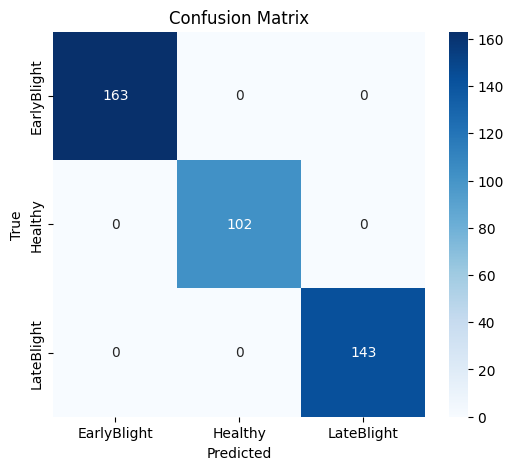

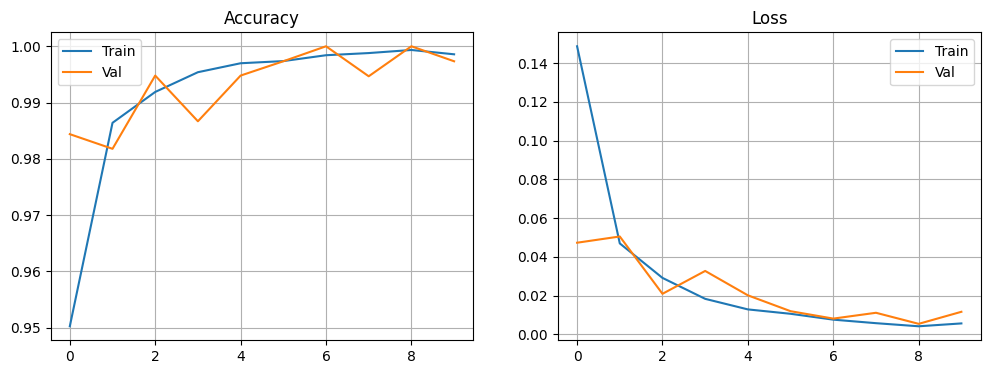

In [10]:
# ============================================================
# RESNET50 PIPELINE (256x256) + FULL EVALUATION + SAVE MODEL
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/pld-foldds/PLD_FOLDDATASET"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10

# ---------------- LOAD DATA ----------------
def load_data(folder):
    paths, labels = [], []
    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        for f in os.listdir(os.path.join(folder, cls)):
            paths.append(os.path.join(folder, cls, f))
            labels.append(idx)

    return np.array(paths), np.array(labels), classes

X_train, y_train, class_names = load_data(TRAIN_DIR)
X_val, y_val, _ = load_data(VAL_DIR)
X_test, y_test, _ = load_data(TEST_DIR)

NUM_CLASSES = len(class_names)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

# ---------------- GENERATOR ----------------
def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)

                img = preprocess_input(img.astype("float32"))
                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, NUM_CLASSES)

# ---------------- MODEL (ResNet50) ----------------
base = ResNet50(weights="imagenet", include_top=False,
                input_shape=(IMG_SIZE, IMG_SIZE, 3))

base.trainable = False  # initial freeze

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs=base.input, outputs=out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ---------------- CALLBACKS (SAVE BEST MODEL) ----------------
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_resnet50.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# ---------------- TRAIN ----------------
history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    validation_data=generator(X_val, y_val),
    validation_steps=max(1, len(X_val)//BATCH_SIZE),
    epochs=EPOCHS,
    callbacks=[checkpoint],
    verbose=1
)

# ---------------- SAVE FINAL MODEL ----------------
model.save("/kaggle/working/final_resnet50.h5")
print("✅ Final model saved")

# ---------------- LOAD BEST MODEL ----------------
model = tf.keras.models.load_model("/kaggle/working/best_resnet50.h5")

# ---------------- TEST ----------------
y_true, y_pred = [], []
test_gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(test_gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ---------------- METRICS ----------------
acc = np.mean(y_true == y_pred)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ---------------- TRAINING CURVES ----------------
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
# ============================================================
# OPTIMIZED DOMAIN ADAPTATION (RESNET50 - HIGH ACCURACY)
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/potatoleafplantvillage/PlantVillageExtended/Test"  # ✅ FIXED
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 15

class_names = ["EarlyBlight", "Healthy", "LateBlight"]

# ============================================================
# DATA LOADING
# ============================================================

paths, labels = [], []

for cls in os.listdir(DATASET_DIR):
    cls_lower = cls.lower()

    if "early" in cls_lower:
        label = 0
    elif "healthy" in cls_lower:
        label = 1
    elif "late" in cls_lower:
        label = 2
    else:
        continue

    cls_dir = os.path.join(DATASET_DIR, cls)

    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.jpg','.png','.jpeg')):
            paths.append(os.path.join(cls_dir, f))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("Total samples:", len(paths))

# ============================================================
# SPLIT
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels, test_size=0.3, stratify=labels, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# ============================================================
# STRONG AUGMENTATION
# ============================================================

def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)
                    if np.random.rand() < 0.4:
                        img = cv2.convertScaleAbs(img, alpha=1.4, beta=40)
                    if np.random.rand() < 0.3:
                        img = cv2.GaussianBlur(img, (5,5), 0)
                    if np.random.rand() < 0.3:
                        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
                    if np.random.rand() < 0.2:
                        img = cv2.add(img, np.random.randint(0,30,img.shape,dtype='uint8'))

                img = preprocess_input(img.astype("float32"))

                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, 3)

# ============================================================
# MODEL
# ============================================================

base = ResNet50(weights="imagenet",
                include_top=False,
                input_shape=(IMG_SIZE, IMG_SIZE, 3))

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(3, activation="softmax")(x)

model = Model(inputs=base.input, outputs=outputs)

# ============================================================
# BETTER FINE-TUNING
# ============================================================

for layer in base.layers[:-50]:
    layer.trainable = False

for layer in base.layers[-50:]:
    layer.trainable = True

# ============================================================
# COSINE LR SCHEDULE
# ============================================================

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=1000
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

# ============================================================
# CALLBACKS
# ============================================================

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_resnet50.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# TRAIN
# ============================================================

history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    validation_data=generator(X_val, y_val),
    validation_steps=max(1, len(X_val)//BATCH_SIZE),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# LOAD BEST MODEL
# ============================================================

model = tf.keras.models.load_model("/kaggle/working/best_resnet50.h5")

# ============================================================
# TEST
# ============================================================

y_true, y_pred = [], []
gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ============================================================
# RESULTS
# ============================================================

print("\n✅ Accuracy:", np.mean(y_true == y_pred))

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Total samples: 2152
Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7483 - loss: 0.8311
Epoch 1: val_accuracy improved from -inf to 0.95000, saving model to /kaggle/working/best_resnet50.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 33s 262ms/step - accuracy: 0.7511 - loss: 0.8259 - val_accuracy: 0.9500 - val_loss: 0.4617 - learning_rate: 9.9456e-05
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9609 - loss: 0.4061
Epoch 2: val_accuracy improved from 0.95000 to 0.99687, saving model to /kaggle/working/best_resnet50.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.9612 - loss: 0.4056 - val_accuracy: 0.9969 - val_loss: 0.3370 - learning_rate: 9.7836e-05
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9875 - loss: 0.3582
Epoch 3: val_accuracy did not improve from 0.99687
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.9875 - loss: 0.3581 - val_accuracy: 0.9969 - val_loss: 0.3320 - learning_rate: 9.5174e-05
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9916 - loss: 0.3453
Epoch 4: val_accuracy improved from 0.99687 to 1.00000, saving model to /kaggle/working/best_resnet50.h5


47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.9916 - loss: 0.3452 - val_accuracy: 1.0000 - val_loss: 0.3170 - learning_rate: 9.1530e-05
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9961 - loss: 0.3295
Epoch 5: val_accuracy did not improve from 1.00000
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.9961 - loss: 0.3295 - val_accuracy: 1.0000 - val_loss: 0.3098 - learning_rate: 8.6982e-05
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9989 - loss: 0.3197
Epoch 6: val_accuracy did not improve from 1.00000
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.9990 - loss: 0.3196 - val_accuracy: 0.9897 - val_loss: 0.3208 - learning_rate: 8.1629e-05
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9978 - loss: 0.3192
Epoch 7: val_accuracy did not improve from 1.00000
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.9978 - loss: 0.3192 - val_accuracy: 0.9966 - val_loss: 0.3057 - learning_rate: 7.5587e-05
Epoch 8/15
4


✅ Accuracy: 0.9969040247678018

📊 Classification Report:
              precision    recall  f1-score   support

 EarlyBlight       1.00      1.00      1.00       150
     Healthy       1.00      0.96      0.98        23
  LateBlight       0.99      1.00      1.00       150

    accuracy                           1.00       323
   macro avg       1.00      0.99      0.99       323
weighted avg       1.00      1.00      1.00       323



In [2]:
# ============================================================
# DENSENET201 PIPELINE (256x256) + FULL EVALUATION + OPTIMIZED
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/datasets/psthakre/pld-foldds/PLD_FOLDDATASET"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10   # 🔥 increased

# ---------------- LOAD DATA ----------------
def load_data(folder):
    paths, labels = [], []
    classes = sorted(os.listdir(folder))

    for idx, cls in enumerate(classes):
        for f in os.listdir(os.path.join(folder, cls)):
            paths.append(os.path.join(folder, cls, f))
            labels.append(idx)

    return np.array(paths), np.array(labels), classes

X_train, y_train, class_names = load_data(TRAIN_DIR)
X_val, y_val, _ = load_data(VAL_DIR)
X_test, y_test, _ = load_data(TEST_DIR)

NUM_CLASSES = len(class_names)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

# ============================================================
# STRONG GENERATOR
# ============================================================

def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)
                    if np.random.rand() < 0.4:
                        img = cv2.convertScaleAbs(img, alpha=1.4, beta=40)
                    if np.random.rand() < 0.3:
                        img = cv2.GaussianBlur(img, (5,5), 0)
                    if np.random.rand() < 0.3:
                        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

                img = preprocess_input(img.astype("float32"))

                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, NUM_CLASSES)

# ============================================================
# MODEL (DenseNet201)
# ============================================================

base = DenseNet201(weights="imagenet",
                   include_top=False,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))

base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)   # 🔥 added
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs=base.input, outputs=out)

# ============================================================
# FINE-TUNING
# ============================================================

for layer in base.layers[:-60]:
    layer.trainable = False

for layer in base.layers[-60:]:
    layer.trainable = True

# ============================================================
# LR + LOSS OPTIMIZATION
# ============================================================

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=1000
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# CALLBACKS
# ============================================================

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_densenet201.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

callbacks = [
    checkpoint,
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# TRAIN
# ============================================================

history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    validation_data=generator(X_val, y_val),
    validation_steps=max(1, len(X_val)//BATCH_SIZE),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# SAVE FINAL MODEL
# ============================================================

model.save("/kaggle/working/final_densenet201.h5")

# ============================================================
# LOAD BEST MODEL
# ============================================================

model = tf.keras.models.load_model("/kaggle/working/best_densenet201.h5")

# ============================================================
# TEST
# ============================================================

y_true, y_pred = [], []
test_gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(test_gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ============================================================
# RESULTS
# ============================================================

acc = np.mean(y_true == y_pred)
print(f"\n✅ Test Accuracy: {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ============================================================
# TRAINING CURVES
# ============================================================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.show()

Train: 18257 Val: 407 Test: 408


I0000 00:00:1777814428.503867      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 64, 64,    │     12,288 │ conv2_block2_0_r

...

 Trainable params: 3,173,635 (12.11 MB)

 Non-trainable params: 16,141,120 (61.57 MB)

Epoch 1/10


I0000 00:00:1777814461.174782     141 service.cc:152] XLA service 0x7f5b944fb260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777814461.174818     141 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777814467.479149     141 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777814502.764855     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


KeyboardInterrupt: 

In [1]:
# ============================================================
# CLEAN DOMAIN ADAPTATION (LEAKAGE-FREE)
# ============================================================

import os, cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
DATASET_DIR = "/kaggle/input/potatoleafplantvillage/PlantVillageExtended"
MODEL_PATH = "/kaggle/working/best_model_A.h5"   # trained on Dataset A

IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10

class_names = ["EarlyBlight", "Healthy", "LateBlight"]

# ============================================================
# LOAD DATASET B
# ============================================================

paths, labels = [], []

for cls in os.listdir(DATASET_DIR):
    cls_lower = cls.lower()

    if "early" in cls_lower:
        label = 0
    elif "healthy" in cls_lower:
        label = 1
    elif "late" in cls_lower:
        label = 2
    else:
        continue

    cls_dir = os.path.join(DATASET_DIR, cls)

    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.jpg','.png','.jpeg')):
            paths.append(os.path.join(cls_dir, f))
            labels.append(label)

paths = np.array(paths)
labels = np.array(labels)

print("Total samples:", len(paths))

# ============================================================
# SPLIT (IMPORTANT)
# ============================================================

# 70% TEST (UNSEEN)
X_temp, X_test, y_temp, y_test = train_test_split(
    paths, labels,
    test_size=0.7,
    stratify=labels,
    random_state=42
)

# Remaining 30% → split into train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.33,   # ~10% val
    stratify=y_temp,
    random_state=42
)

print("Adapt Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

# ============================================================
# GENERATOR
# ============================================================

def generator(paths, labels, augment=False):
    while True:
        idxs = np.random.permutation(len(paths))

        for i in range(0, len(paths), BATCH_SIZE):
            batch = idxs[i:i+BATCH_SIZE]
            imgs, labs = [], []

            for j in batch:
                img = cv2.imread(paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                if augment:
                    if np.random.rand() < 0.5:
                        img = cv2.flip(img, 1)
                    if np.random.rand() < 0.4:
                        img = cv2.convertScaleAbs(img, alpha=1.3, beta=40)
                    if np.random.rand() < 0.3:
                        img = cv2.GaussianBlur(img, (5,5), 0)

                img = preprocess_input(img.astype("float32"))

                imgs.append(img)
                labs.append(labels[j])

            yield np.array(imgs), tf.keras.utils.to_categorical(labs, 3)

# ============================================================
# LOAD MODEL TRAINED ON DATASET A
# ============================================================

model = load_model(MODEL_PATH)

# ============================================================
# FINE-TUNING
# ============================================================

# Freeze most layers
for layer in model.layers[:-40]:
    layer.trainable = False

# Unfreeze last layers
for layer in model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

# ============================================================
# CALLBACKS
# ============================================================

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_adapted_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

# ============================================================
# TRAIN (ADAPTATION)
# ============================================================

history = model.fit(
    generator(X_train, y_train, augment=True),
    steps_per_epoch=max(1, len(X_train)//BATCH_SIZE),
    validation_data=generator(X_val, y_val),
    validation_steps=max(1, len(X_val)//BATCH_SIZE),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# LOAD BEST MODEL
# ============================================================

model = load_model("/kaggle/working/best_adapted_model.h5")

# ============================================================
# TEST (UNSEEN DATA)
# ============================================================

y_true, y_pred = [], []
gen = generator(X_test, y_test)

for _ in range(len(X_test)//BATCH_SIZE + 1):
    imgs, labs = next(gen)
    preds = model.predict(imgs, verbose=0)

    y_true.extend(np.argmax(labs, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true[:len(X_test)])
y_pred = np.array(y_pred[:len(X_test)])

# ============================================================
# RESULTS
# ============================================================

acc = np.mean(y_true == y_pred)
print(f"\n✅ Final Test Accuracy (Domain Adaptation): {acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

2026-05-03 13:04:15.784488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777813455.981455      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777813456.039347      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777813456.502492      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777813456.502541      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777813456.502544      57 computation_placer.cc:177] computation placer alr

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/kaggle/working/densenet201_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)